In [ ]:
!pip install minari torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 753.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F


import shutil
import minari

In [ ]:
# source_uci_path = "/content/drive/MyDrive/eecs_295p_gnn_research_report/uci"
# target_uci_path = "/content/local_minari_data/uci"

# # remove old partial copy
# if os.path.exists(target_uci_path):
#     shutil.rmtree(target_uci_path)
#     print("Old local copy removed.")

# # copy again
# shutil.copytree(source_uci_path, target_uci_path)
# print("Re-copy completed.")

# # verify
# print("Local folders now:")
# print(sorted(os.listdir(target_uci_path)))



Re-copy completed.
Local folders now:
['baseline_dataset_metric_comparison.png', 'baseline_dataset_metric_comparison_large.png', 'baseline_final_metric_bars.png', 'baseline_final_metric_bars_large.png', 'battle_v4-heuristic', 'battle_v4-mixed', 'battle_v4-random', 'battle_v4-testv4', 'dgn_dataset_metric_comparison.png', 'dgn_dataset_metric_comparison_large.png', 'dgn_final_metric_bars.png', 'dgn_final_metric_bars_large.png', 'final_report_outputs', 'large', 'medium', 'models', 'namespace_metadata.json', 'small']


In [ ]:
# test_dataset = minari.load_dataset("uci/battle_v4-testv4/battle_v4-random-small_part000-v4")
# first_ep = next(test_dataset.iterate_episodes())

# print("Observation keys:", first_ep.observations.keys())

# node_key = "node_feat" if "node_feat" in first_ep.observations else "node_features"
# print("Node shape:", first_ep.observations[node_key][0].shape)
# print("Actions shape:", np.array(first_ep.actions).shape)
# print("Episode length:", len(first_ep.actions))
# print("Num actions:", int(np.max(first_ep.actions)) + 1)

In [ ]:
# os.environ["MINARI_DATASETS_PATH"] = "/content/local_minari_data"
# print("MINARI_DATASETS_PATH =", os.environ["MINARI_DATASETS_PATH"])

# # quick check: one TRAIN dataset (medium, part000)
# train_dataset = minari.load_dataset("uci/battle_v4-random/battle_v4-random-medium_part000-v4")
# print("Train sample loaded:", train_dataset)

# # quick check: one TEST dataset (medium, held-out part006)
# test_dataset = minari.load_dataset("uci/battle_v4-random/battle_v4-random-medium_part006-v4")
# print("Test sample loaded:", test_dataset)
os.environ["MINARI_DATASETS_PATH"] = "/content/local_minari_data"
print("MINARI_DATASETS_PATH =", os.environ["MINARI_DATASETS_PATH"])

train_ids = [
    f"uci/medium/battle_v4-medium_part{idx:03d}-v5"
    for idx in range(6)
]

test_ids = [
    f"uci/medium/battle_v4-medium_part{idx:03d}-v5"
    for idx in range(6, 8)
]

for ds_id in train_ids:
    dataset = minari.load_dataset(ds_id)
    print("train loaded:", ds_id, dataset)

for ds_id in test_ids:
    dataset = minari.load_dataset(ds_id)
    print("test loaded :", ds_id, dataset)

MINARI_DATASETS_PATH = /content/local_minari_data
train loaded: uci/medium/battle_v4-medium_part000-v5 <minari.dataset.minari_dataset.MinariDataset object at 0x7bc56a1c2ed0>
train loaded: uci/medium/battle_v4-medium_part001-v5 <minari.dataset.minari_dataset.MinariDataset object at 0x7bc56a3a5310>
train loaded: uci/medium/battle_v4-medium_part002-v5 <minari.dataset.minari_dataset.MinariDataset object at 0x7bc56c0ceab0>
train loaded: uci/medium/battle_v4-medium_part003-v5 <minari.dataset.minari_dataset.MinariDataset object at 0x7bc56c0bc080>
train loaded: uci/medium/battle_v4-medium_part004-v5 <minari.dataset.minari_dataset.MinariDataset object at 0x7bc56a1d7110>
train loaded: uci/medium/battle_v4-medium_part005-v5 <minari.dataset.minari_dataset.MinariDataset object at 0x7bc56c0bdb20>
test loaded : uci/medium/battle_v4-medium_part006-v5 <minari.dataset.minari_dataset.MinariDataset object at 0x7bc56b13b4a0>
test loaded : uci/medium/battle_v4-medium_part007-v5 <minari.dataset.minari_datase

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
TRAIN_DATASET_GROUPS = {
    "small": [f"uci/small/battle_v4-small_part000-v5"],
    "medium": [f"uci/medium/battle_v4-medium_part{idx:03d}-v5" for idx in range(6)],
    "large": [f"uci/large/battle_v4-large_part{idx:03d}-v5" for idx in range(16)],
}

TEST_DATASET_GROUPS = {
    "small": [f"uci/small/battle_v4-small_part001-v5"],
    "medium": [f"uci/medium/battle_v4-medium_part{idx:03d}-v5" for idx in range(6, 8)],
    "large": [f"uci/large/battle_v4-large_part{idx:03d}-v5" for idx in range(16, 20)],
}

MAX_EPISODES_TRAIN_PER_PART = 2
MAX_EPISODES_TEST_PER_PART = 1
MAX_STEPS_PER_EPISODE = None
LEARNING_RATE = 0.01
HIDDEN_DIM = 64

Helper functions to inspect dataset structure

In [ ]:
def load_dataset_list(dataset_id_list):
    datasets = []
    for dataset_id in dataset_id_list:
        ds = minari.load_dataset(dataset_id)
        datasets.append(ds)
    return datasets


def get_first_episode_from_dataset_list(dataset_list):
    for ds in dataset_list:
        try:
            return next(ds.iterate_episodes())
        except StopIteration:
            continue
    raise ValueError("No episodes found in dataset list.")


def get_node_key(first_ep):
    obs = first_ep.observations

    if isinstance(obs, dict):
        if "node_feat" in obs:
            return "node_feat"
        elif "node_features" in obs:
            return "node_features"
        else:
            raise KeyError(
                f"Could not find 'node_feat' or 'node_features'. "
                f"Available keys: {list(obs.keys())}"
            )
    else:
        raise TypeError(f"Expected observations to be a dict, got: {type(obs)}")


def infer_shapes(first_ep):
    node_key = get_node_key(first_ep)

    first_obs = np.array(first_ep.observations[node_key][0])

    if first_obs.ndim != 2:
        raise ValueError(
            f"Expected observation shape [num_nodes, num_node_features], got {first_obs.shape}"
        )

    num_nodes = first_obs.shape[0]
    num_node_features = first_obs.shape[1]

    sample_actions = np.array(first_ep.actions)
    if sample_actions.size == 0:
        raise ValueError("No actions found in first episode.")

    num_actions = int(np.max(sample_actions)) + 1

    return node_key, num_nodes, num_node_features, num_actions



**Graph Helper Functions**

In [ ]:
def count_edges(adj, directed=False):
    adj_bin = (adj > 0).astype(np.float32)
    if directed:
        return int(np.sum(adj_bin))
    return int(np.sum(adj_bin) / 2)


def graph_density(adj, directed=False):
    adj_bin = (adj > 0).astype(np.float32)
    n = adj_bin.shape[0]

    if n <= 1:
        return 0.0

    if directed:
        possible = n * (n - 1)
        return float(np.sum(adj_bin) / possible)

    possible = n * (n - 1) / 2
    return float((np.sum(adj_bin) / 2) / possible)


def build_adj_from_edge_index(edge_index, num_nodes, make_undirected=True):
    adj = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    edge_index = np.array(edge_index)

    if edge_index.size == 0:
        return adj

    if edge_index.ndim != 2 or edge_index.shape[0] != 2:
        raise ValueError(f"edge_index should have shape [2, num_edges], got {edge_index.shape}")

    src, dst = edge_index[0], edge_index[1]
    adj[src, dst] = 1.0

    if make_undirected:
        adj[dst, src] = 1.0

    np.fill_diagonal(adj, 0.0)
    return adj

**Graph properties print block**

In [ ]:
def print_graph_properties(dataset_name, dataset_list, make_undirected=True):
    first_ep = get_first_episode_from_dataset_list(dataset_list)
    node_key, num_nodes, num_node_features, num_actions = infer_shapes(first_ep)

    obs = first_ep.observations

    if "edge_index" in obs:
        edge_index = obs["edge_index"][0]
        adj = build_adj_from_edge_index(
            edge_index=edge_index,
            num_nodes=num_nodes,
            make_undirected=make_undirected
        )
        graph_source = "Real graph from edge_index"
    else:
        adj = np.ones((num_nodes, num_nodes), dtype=np.float32)
        np.fill_diagonal(adj, 0.0)
        graph_source = "Fallback fully connected graph"

    print("=" * 70)
    print(f"GRAPH PROPERTIES FOR: {dataset_name}")
    print("=" * 70)
    print(f"Observation key used                 : {node_key}")
    print(f"Number of nodes                      : {num_nodes}")
    print(f"Node meaning                         : Each node represents one agent/entity in the environment.")
    print(f"Node feature dimension               : {num_node_features}")
    print(f"Action space size                    : {num_actions}")
    print(f"Adjacency matrix shape               : {adj.shape}")
    print(f"Graph source                         : {graph_source}")
    print(f"Graph treated as undirected?         : {'Yes' if make_undirected else 'No'}")
    print(f"Is graph represented by adjacency matrix? : Yes")
    print(f"Number of edges                      : {count_edges(adj, directed=not make_undirected)}")
    print(f"Graph density                        : {graph_density(adj, directed=not make_undirected):.4f}")
    print(f"Self loops                           : {'Yes' if np.any(np.diag(adj) > 0) else 'No'}")
    print()
    print("Interpretation:")
    print("- Nodes = agents/entities in the multi-agent environment.")
    print("- Edges = communication links between agents.")
    print("- Adjacency matrix entry A[i,j] = 1 means node i is connected to node j.")
    print("=" * 70)

    return adj

**EDA**

In [ ]:
import pandas as pd

def dataset_group_eda(dataset_name, dataset_list, max_episodes_per_part=3):
    first_ep = get_first_episode_from_dataset_list(dataset_list)
    node_key = get_node_key(first_ep)

    episode_lengths = []
    all_actions = []

    for ds in dataset_list:
        for ep_idx, ep in enumerate(ds.iterate_episodes()):
            if ep_idx >= max_episodes_per_part:
                break

            steps = len(ep.actions)
            episode_lengths.append(steps)

            ep_actions = np.array(ep.actions).reshape(-1)
            all_actions.extend(ep_actions.tolist())

    all_actions = np.array(all_actions)

    if len(episode_lengths) == 0:
        raise ValueError(f"No episodes found for dataset group: {dataset_name}")

    print("=" * 70)
    print(f"EDA FOR TRAIN GROUP: {dataset_name}")
    print("=" * 70)
    print(f"Observation key used        : {node_key}")
    print(f"Datasets in group           : {len(dataset_list)}")
    print(f"Episodes inspected          : {len(episode_lengths)}")
    print(f"Average episode length      : {np.mean(episode_lengths):.2f}")
    print(f"Min episode length          : {np.min(episode_lengths)}")
    print(f"Max episode length          : {np.max(episode_lengths)}")
    print(f"Std episode length          : {np.std(episode_lengths):.2f}")
    print(f"Total action samples        : {len(all_actions)}")
    print()

    unique_actions, counts = np.unique(all_actions, return_counts=True)
    action_df = pd.DataFrame({
        "action": unique_actions,
        "count": counts,
        "percentage": counts / counts.sum() * 100
    }).sort_values("action").reset_index(drop=True)

    print(action_df.to_string(index=False))

    return {
        "node_key": node_key,
        "episode_lengths": episode_lengths,
        "all_actions": all_actions,
        "action_df": action_df
    }

**EDA Plotting**

In [ ]:
import matplotlib.pyplot as plt

def plot_eda(eda_results, dataset_name):
    episode_lengths = eda_results["episode_lengths"]
    action_df = eda_results["action_df"]

    plt.figure(figsize=(8, 5))
    plt.hist(episode_lengths, bins=10)
    plt.title(f"Episode Length Distribution - {dataset_name}")
    plt.xlabel("Episode length")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(action_df["action"], action_df["count"])
    plt.title(f"Action Distribution - {dataset_name}")
    plt.xlabel("Action")
    plt.ylabel("Count")
    plt.xticks(action_df["action"])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**CommNet model**

In [ ]:
class CommNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_actions, num_comm_steps=2):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.comm = nn.Linear(hidden_dim, hidden_dim)
        self.policy_head = nn.Linear(hidden_dim, num_actions)
        self.num_comm_steps = num_comm_steps

    def forward(self, x, adj):
        x = x.float()
        adj = adj.float().clone()
        adj.fill_diagonal_(0)

        h = F.relu(self.encoder(x))

        for _ in range(self.num_comm_steps):
            deg = adj.sum(dim=1, keepdim=True).clamp(min=1.0)
            m = torch.matmul(adj, h) / deg
            h = F.relu(h + self.comm(m))

        logits = self.policy_head(h)
        return logits

**Why use CommNet?**

We use CommNet because it is specifically designed for multi-agent settings where coordination depends on communication between agents. In our implementation, each agent first encodes its local observation, then exchanges information with neighboring agents through the adjacency matrix, which determines who can communicate with whom. This makes CommNet well suited for graph topology ablation, because changing the adjacency matrix directly changes the amount and pattern of information flow between agents. As a result, we can evaluate how reduced or restricted communication affects coordination and model performance.

**Ablation**

In [ ]:
import numpy as np

def adjacency_drop_existing(existing_adj, drop_ratio=0.5, seed=42):
    """Drop a percentage of existing undirected edges from the real graph."""
    rng = np.random.default_rng(seed)

    adj = (existing_adj > 0).astype(np.float32).copy()
    np.fill_diagonal(adj, 0.0)

    upper_edges = np.argwhere(np.triu(adj, k=1) > 0)
    num_drop = int(drop_ratio * len(upper_edges))

    if num_drop > 0 and len(upper_edges) > 0:
        drop_indices = rng.choice(len(upper_edges), size=num_drop, replace=False)
        for idx in drop_indices:
            i, j = upper_edges[idx]
            adj[i, j] = 0.0
            adj[j, i] = 0.0

    return adj


def adjacency_k_neighbors_from_real_graph(existing_adj, k=2, seed=42):
    """
    Restrict each node to at most k neighbors chosen from its existing neighbors
    in the real graph.
    """
    rng = np.random.default_rng(seed)

    existing_adj = (existing_adj > 0).astype(np.float32)
    np.fill_diagonal(existing_adj, 0.0)

    num_nodes = existing_adj.shape[0]
    new_adj = np.zeros_like(existing_adj, dtype=np.float32)

    for i in range(num_nodes):
        neighbors = np.where(existing_adj[i] > 0)[0]
        neighbors = neighbors[neighbors != i]

        if len(neighbors) <= k:
            chosen = neighbors
        else:
            chosen = rng.choice(neighbors, size=k, replace=False)

        new_adj[i, chosen] = 1.0

    new_adj = np.maximum(new_adj, new_adj.T)
    np.fill_diagonal(new_adj, 0.0)

    return new_adj


def apply_ablation_to_real_graph(real_adj, mode, seed=42):
    num_nodes = real_adj.shape[0]

    real_adj = (real_adj > 0).astype(np.float32)
    np.fill_diagonal(real_adj, 0.0)

    if mode == "baseline":
        return real_adj.copy()

    elif mode == "drop_50":
        return adjacency_drop_existing(real_adj, drop_ratio=0.50, seed=seed)

    elif mode == "drop_70":
        return adjacency_drop_existing(real_adj, drop_ratio=0.70, seed=seed)

    elif mode == "no_comm":
        return np.zeros((num_nodes, num_nodes), dtype=np.float32)

    elif mode == "k2_neighbors":
        return adjacency_k_neighbors_from_real_graph(real_adj, k=2, seed=seed)

    else:
        raise ValueError(f"Unknown ablation mode: {mode}")

**Step-data helper**

In [ ]:
def prepare_step_data(obs_t, act_t):
    """
    obs_t: one timestep observation for all nodes
    act_t: one timestep action(s)
    """
    x = torch.tensor(obs_t, dtype=torch.float32, device=device)
    act_t = np.array(act_t)

    if act_t.ndim == 0:
        y = torch.tensor([int(act_t)], dtype=torch.long, device=device)
    else:
        y = torch.tensor(act_t.reshape(-1), dtype=torch.long, device=device)

    return x, y

**Training function**

In [ ]:
def train_one_experiment_on_group(
    dataset_list,
    ablation_mode,
    hidden_dim=64,
    lr=0.01,
    max_episodes_per_part=2,
    max_steps=None
):
    first_ep = get_first_episode_from_dataset_list(dataset_list)
    node_key, num_nodes, num_node_features, num_actions = infer_shapes(first_ep)

    model = CommNet(num_node_features, hidden_dim, num_actions, num_comm_steps=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    acc_history = []
    last_adj_used = None

    model.train()

    for ds in dataset_list:
        for ep_idx, ep in enumerate(ds.iterate_episodes()):
            if ep_idx >= max_episodes_per_part:
                break

            observations = ep.observations[node_key]
            actions = ep.actions

            steps_to_use = len(actions) if max_steps is None else min(len(actions), max_steps)
            if steps_to_use == 0:
                continue

            optimizer.zero_grad()
            episode_loss = 0.0

            for t in range(steps_to_use):
                obs_t = observations[t]
                act_t = actions[t]

                if "edge_index" not in ep.observations:
                    raise KeyError("edge_index not found in episode observations.")

                edge_index_t = np.array(ep.observations["edge_index"][t])
                real_adj = np.zeros((num_nodes, num_nodes), dtype=np.float32)

                if edge_index_t.size > 0 and edge_index_t.ndim == 2 and edge_index_t.shape[0] == 2:
                    real_adj[edge_index_t[0], edge_index_t[1]] = 1.0
                    real_adj[edge_index_t[1], edge_index_t[0]] = 1.0

                np.fill_diagonal(real_adj, 0.0)

                ablated_adj_np = apply_ablation_to_real_graph(real_adj, ablation_mode)

                # last_adj_used = ablated_adj_np.copy()
                if last_adj_used is None:
                     last_adj_used = ablated_adj_np.copy()

                adj_tensor = torch.from_numpy(ablated_adj_np).float().to(device)

                x, y = prepare_step_data(obs_t, act_t)
                logits = model(x, adj_tensor)

                min_len = min(logits.shape[0], y.shape[0])
                logits = logits[:min_len]
                y = y[:min_len]

                loss = F.cross_entropy(logits, y)
                episode_loss = episode_loss + loss

                preds = torch.argmax(logits, dim=1)
                acc = (preds == y).float().mean().item()

                loss_history.append(loss.item())
                acc_history.append(acc)

            avg_episode_loss = episode_loss / steps_to_use
            avg_episode_loss.backward()
            optimizer.step()

    return {
        "model": model,
        "adjacency": last_adj_used,
        "train_loss_history": loss_history,
        "train_acc_history": acc_history,
        "train_final_loss": loss_history[-1] if len(loss_history) > 0 else None,
        "train_final_acc": acc_history[-1] if len(acc_history) > 0 else None,
        "train_mean_loss": float(np.mean(loss_history)) if len(loss_history) > 0 else None,
        "train_mean_acc": float(np.mean(acc_history)) if len(acc_history) > 0 else None,
    }

**Evaluation function**

In [ ]:
@torch.no_grad()
def evaluate_model_on_group(
    model,
    dataset_list,
    ablation_mode,
    max_episodes_per_part=1,
    max_steps=None
):
    first_ep = get_first_episode_from_dataset_list(dataset_list)
    node_key, num_nodes, _, _ = infer_shapes(first_ep)

    model.eval()

    loss_history = []
    acc_history = []
    last_adj_used = None

    for ds in dataset_list:
        for ep_idx, ep in enumerate(ds.iterate_episodes()):
            if ep_idx >= max_episodes_per_part:
                break

            observations = ep.observations[node_key]
            actions = ep.actions

            steps_to_use = len(actions) if max_steps is None else min(len(actions), max_steps)

            for t in range(steps_to_use):
                obs_t = observations[t]
                act_t = actions[t]

                if "edge_index" not in ep.observations:
                    raise KeyError("edge_index not found in episode observations.")

                edge_index_t = np.array(ep.observations["edge_index"][t])
                real_adj = np.zeros((num_nodes, num_nodes), dtype=np.float32)

                if edge_index_t.size > 0 and edge_index_t.ndim == 2 and edge_index_t.shape[0] == 2:
                    real_adj[edge_index_t[0], edge_index_t[1]] = 1.0
                    real_adj[edge_index_t[1], edge_index_t[0]] = 1.0

                np.fill_diagonal(real_adj, 0.0)

                ablated_adj_np = apply_ablation_to_real_graph(real_adj, ablation_mode)

                # last_adj_used = ablated_adj_np.copy()
                if last_adj_used is None:
                     last_adj_used = ablated_adj_np.copy()

                adj_tensor = torch.from_numpy(ablated_adj_np).float().to(device)

                x, y = prepare_step_data(obs_t, act_t)
                logits = model(x, adj_tensor)

                min_len = min(logits.shape[0], y.shape[0])
                logits = logits[:min_len]
                y = y[:min_len]

                loss = F.cross_entropy(logits, y)

                preds = torch.argmax(logits, dim=1)
                acc = (preds == y).float().mean().item()

                loss_history.append(loss.item())
                acc_history.append(acc)

    return {
        "adjacency": last_adj_used,
        "test_loss_history": loss_history,
        "test_acc_history": acc_history,
        "test_final_loss": loss_history[-1] if len(loss_history) > 0 else None,
        "test_final_acc": acc_history[-1] if len(acc_history) > 0 else None,
        "test_mean_loss": float(np.mean(loss_history)) if len(loss_history) > 0 else None,
        "test_mean_acc": float(np.mean(acc_history)) if len(acc_history) > 0 else None,
    }

**EDA execution**


Loading training dataset group: small
Number of parts: 1
GRAPH PROPERTIES FOR: small
Observation key used                 : node_feat
Number of nodes                      : 40
Node meaning                         : Each node represents one agent/entity in the environment.
Node feature dimension               : 12
Action space size                    : 21
Adjacency matrix shape               : (40, 40)
Graph source                         : Real graph from edge_index
Graph treated as undirected?         : Yes
Is graph represented by adjacency matrix? : Yes
Number of edges                      : 142
Graph density                        : 0.1821
Self loops                           : No

Interpretation:
- Nodes = agents/entities in the multi-agent environment.
- Edges = communication links between agents.
- Adjacency matrix entry A[i,j] = 1 means node i is connected to node j.
EDA FOR TRAIN GROUP: small
Observation key used        : node_feat
Datasets in group           : 1
Episodes insp

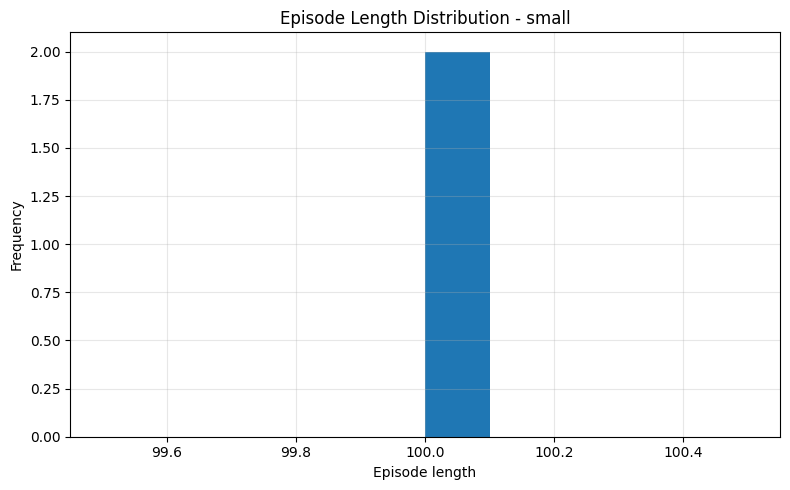

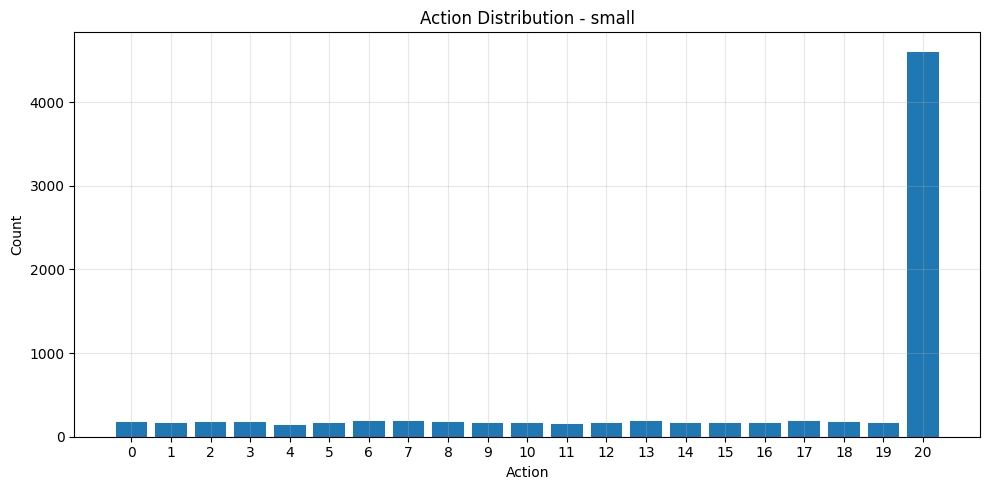


Loading training dataset group: medium
Number of parts: 6
GRAPH PROPERTIES FOR: medium
Observation key used                 : node_feat
Number of nodes                      : 162
Node meaning                         : Each node represents one agent/entity in the environment.
Node feature dimension               : 12
Action space size                    : 21
Adjacency matrix shape               : (162, 162)
Graph source                         : Real graph from edge_index
Graph treated as undirected?         : Yes
Is graph represented by adjacency matrix? : Yes
Number of edges                      : 702
Graph density                        : 0.0538
Self loops                           : No

Interpretation:
- Nodes = agents/entities in the multi-agent environment.
- Edges = communication links between agents.
- Adjacency matrix entry A[i,j] = 1 means node i is connected to node j.
EDA FOR TRAIN GROUP: medium
Observation key used        : node_feat
Datasets in group           : 6
Episode

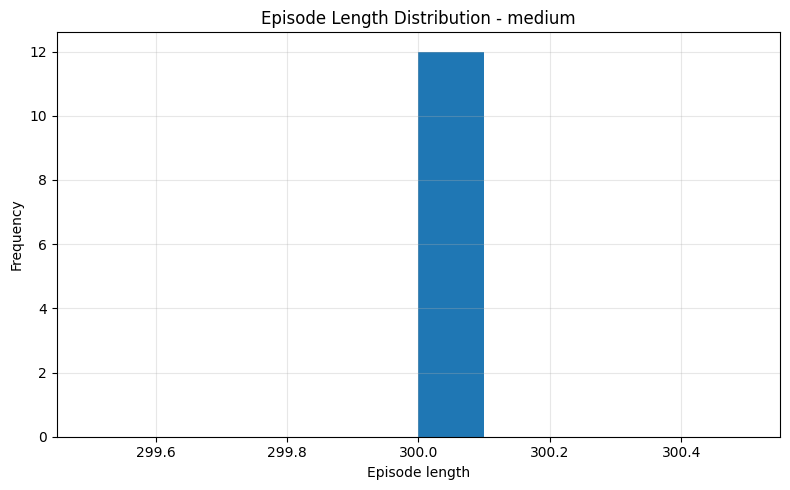

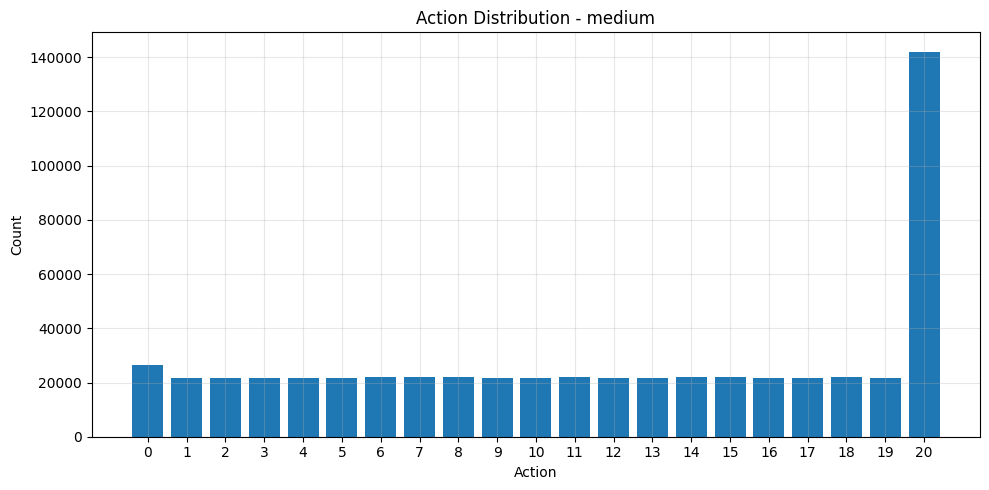


Loading training dataset group: large
Number of parts: 16
GRAPH PROPERTIES FOR: large
Observation key used                 : node_feat
Number of nodes                      : 162
Node meaning                         : Each node represents one agent/entity in the environment.
Node feature dimension               : 12
Action space size                    : 21
Adjacency matrix shape               : (162, 162)
Graph source                         : Real graph from edge_index
Graph treated as undirected?         : Yes
Is graph represented by adjacency matrix? : Yes
Number of edges                      : 702
Graph density                        : 0.0538
Self loops                           : No

Interpretation:
- Nodes = agents/entities in the multi-agent environment.
- Edges = communication links between agents.
- Adjacency matrix entry A[i,j] = 1 means node i is connected to node j.
EDA FOR TRAIN GROUP: large
Observation key used        : node_feat
Datasets in group           : 16
Episodes

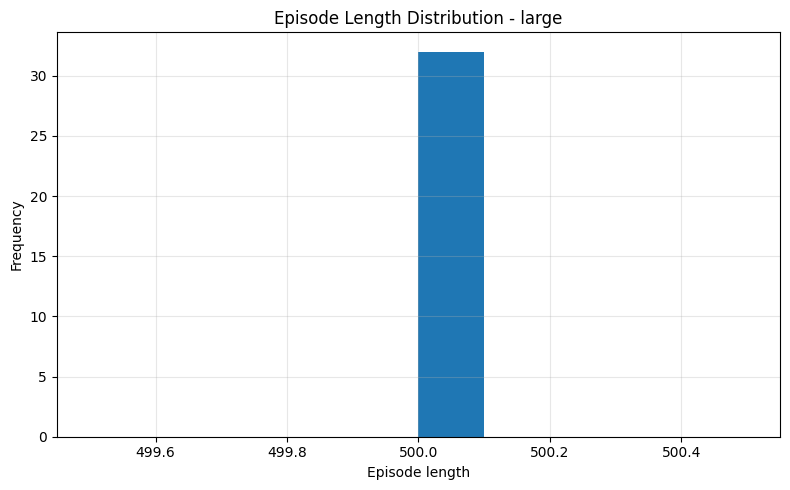

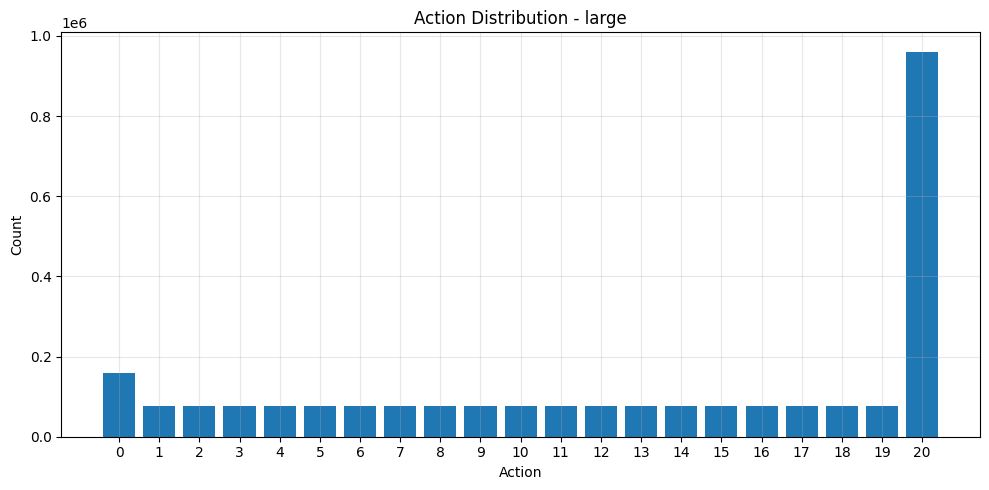

In [ ]:
all_eda = {}

for name, dataset_id_list in TRAIN_DATASET_GROUPS.items():
    print(f"\nLoading training dataset group: {name}")
    print(f"Number of parts: {len(dataset_id_list)}")

    dataset_list = load_dataset_list(dataset_id_list)

    print_graph_properties(name, dataset_list)

    eda_results = dataset_group_eda(name, dataset_list, max_episodes_per_part=2)
    all_eda[name] = eda_results

    plot_eda(eda_results, name)


**Small dataset**

The small dataset shows a very strong dominance of action 20, which accounts for about 57.6% of all actions. The remaining actions are each used much less frequently, around 2% each. This suggests that the small dataset is heavily biased toward one repeated behavior pattern.


**Medium dataset**

In the medium dataset, action 20 is still the most frequent action, at about 24.4%, but the other actions are much more evenly distributed, mostly around 3.7% to 3.8% each. This indicates a more balanced action distribution than the small dataset, while still showing a preference for action 20.

**Large dataset**

In the large dataset, action 20 again dominates the distribution at about 37.1%. The remaining actions are mostly around 3.0%, with action 0 slightly higher at about 6.1%. This suggests that the large dataset also has structured behavior, but it is less extreme than the small dataset and less balanced than the medium dataset.

## Initial Findings from Graph Properties and EDA

The three training dataset groups in the updated v5 dataset are small, medium, and large. All three use **21 discrete actions** and **12 node features per node**, but they differ in graph size and episode length. The **small** dataset contains **40 nodes **and **142 undirected edges**, with a graph density of about** 0.1821**. The medium and **large** datasets each contain **162 nodes and 702 undirected edges**, with a graph **density of about 0.0538**.


The EDA shows that each dataset has a fixed episode length: **100 steps for small**, **300 steps for medium**, and **500 steps for large**. The action distributions also differ across dataset sizes. In all three datasets, **action 20 is the most frequent action**, but its dominance varies: it is strongest in the **small** dataset, moderate in the **large** dataset, and lower in the **medium** dataset. This suggests that the updated datasets encode different behavior patterns across scales, which makes them useful for analyzing how graph topology ablation affects CommNet performance under different environment sizes and action distributions.

# Reason to Choosing Medium Data set for Graph Ablation

We chose the medium dataset because it provides a good balance between realism and computational cost. It uses the same 162-agent communication graph as the large dataset, which allows us to study meaningful communication patterns, but the episode length and dataset size are smaller, making the ablation experiments more computationally manageable. Additionally, the action distribution in the medium dataset is more balanced than in the small dataset, which makes it better suited for evaluating how communication changes affect model performance.

# Experiments

In [ ]:
ABLATION_MODES = ["baseline", "drop_50", "drop_70", "k2_neighbors", "no_comm"]

def fmt(x):
    return f"{x:.4f}" if x is not None else "None"

experiment_results = {}

for name in ["medium"]:
    print(f"\nRunning experiments for group: {name}")

    train_dataset_list = load_dataset_list(TRAIN_DATASET_GROUPS[name])
    test_dataset_list = load_dataset_list(TEST_DATASET_GROUPS[name])

    experiment_results[name] = {}

    for mode in ABLATION_MODES:
        print(f"  -> {mode}")

        train_result = train_one_experiment_on_group(
            dataset_list=train_dataset_list,
            ablation_mode=mode,
            hidden_dim=HIDDEN_DIM,
            lr=LEARNING_RATE,
            max_episodes_per_part=MAX_EPISODES_TRAIN_PER_PART,
            max_steps=MAX_STEPS_PER_EPISODE
        )

        test_result = evaluate_model_on_group(
            model=train_result["model"],
            dataset_list=test_dataset_list,
            ablation_mode=mode,
            max_episodes_per_part=MAX_EPISODES_TEST_PER_PART,
            max_steps=MAX_STEPS_PER_EPISODE
        )

        merged_result = {**train_result, **test_result}
        merged_result["train_adjacency"] = train_result["adjacency"]
        merged_result["test_adjacency"] = test_result["adjacency"]

        experiment_results[name][mode] = merged_result

        print(f"     train mean loss: {fmt(merged_result['train_mean_loss'])}")
        print(f"     train mean acc : {fmt(merged_result['train_mean_acc'])}")
        print(f"     test mean loss : {fmt(merged_result['test_mean_loss'])}")
        print(f"     test mean acc  : {fmt(merged_result['test_mean_acc'])}")


Running experiments for group: medium
  -> baseline
     train mean loss: 2.8779
     train mean acc : 0.2483
     test mean loss : 2.0263
     test mean acc  : 0.5480
  -> drop_50
     train mean loss: 2.9287
     train mean acc : 0.1965
     test mean loss : 2.0417
     test mean acc  : 0.5324
  -> drop_70
     train mean loss: 2.8918
     train mean acc : 0.2329
     test mean loss : 2.0707
     test mean acc  : 0.5324
  -> k2_neighbors
     train mean loss: 2.8747
     train mean acc : 0.2343
     test mean loss : 2.0405
     test mean acc  : 0.5324
  -> no_comm
     train mean loss: 2.8597
     train mean acc : 0.2250
     test mean loss : 2.0477
     test mean acc  : 0.5324


**Summary Table**

In [ ]:
summary_rows = []

for dataset_name, results_dict in experiment_results.items():
    for mode, result in results_dict.items():
        adj = result["train_adjacency"]

        summary_rows.append({
            "dataset": dataset_name,
            "experiment": mode,
            "num_nodes": adj.shape[0] if adj is not None else None,
            "num_edges": count_edges(adj, directed=False) if adj is not None else None,
            "density": graph_density(adj, directed=False) if adj is not None else None,
            "train_mean_loss": result["train_mean_loss"],
            "train_mean_accuracy": result["train_mean_acc"],
            "train_final_loss": result["train_final_loss"],
            "train_final_accuracy": result["train_final_acc"],
            "test_mean_loss": result["test_mean_loss"],
            "test_mean_accuracy": result["test_mean_acc"],
            "test_final_loss": result["test_final_loss"],
            "test_final_accuracy": result["test_final_acc"]
        })

summary_df = pd.DataFrame(summary_rows)

numeric_cols = [
    "density",
    "train_mean_loss", "train_mean_accuracy",
    "train_final_loss", "train_final_accuracy",
    "test_mean_loss", "test_mean_accuracy",
    "test_final_loss", "test_final_accuracy"
]

summary_df[numeric_cols] = summary_df[numeric_cols].round(4)

print(summary_df.to_string(index=False))

dataset   experiment  num_nodes  num_edges  density  train_mean_loss  train_mean_accuracy  train_final_loss  train_final_accuracy  test_mean_loss  test_mean_accuracy  test_final_loss  test_final_accuracy
 medium     baseline        162        702   0.0538           2.8779               0.2483            3.2740                0.0432          2.0263              0.5480           2.6383               0.2963
 medium      drop_50        162        351   0.0269           2.9287               0.1965            3.4039                0.0432          2.0417              0.5324           2.7212               0.2654
 medium      drop_70        162        211   0.0162           2.8918               0.2329            3.2116                0.0432          2.0707              0.5324           2.6316               0.2654
 medium k2_neighbors        162        283   0.0217           2.8747               0.2343            3.2632                0.0432          2.0405              0.5324           2.6298  

The graph topology ablation experiments reduced the communication network from 702 edges in the baseline to 351 edges in Drop50, 211 edges in Drop70, 283 edges in k2_neighbors, and 0 edges in no_comm. The baseline graph was already sparse, with a density of about 0.0538, meaning that only a small fraction of all possible communication links were active.

Training performance remained relatively similar across all settings, which shows that the model is not highly sensitive to communication changes during training. However, on the test set, the baseline achieved the lowest test mean loss (2.0263), while all ablated settings produced slightly higher loss. Among the ablations, k2_neighbors and Drop50 remained closest to the baseline, while Drop70 showed the largest increase in test loss. Overall, these results suggest that communication topology does matter, and reducing communication slightly worsens performance, although the effect is not very large.

Test accuracy changed much less than test loss. This is likely because of how the actions are distributed in the dataset. The medium dataset is not perfectly balanced, and one action—especially action 20 (idle state)—appears much more frequently than the others. Because of this imbalance, the model can still achieve similar accuracy across different settings by predicting the most common actions correctly, even if it performs worse on less frequent actions.

On the other hand, cross-entropy loss is more sensitive to these differences, since it takes into account the confidence of predictions and class imbalance. This is why loss gives a clearer picture of how communication changes affect performance compared to accuracy.

**Plotting Test Loss vs Graph Density plot**



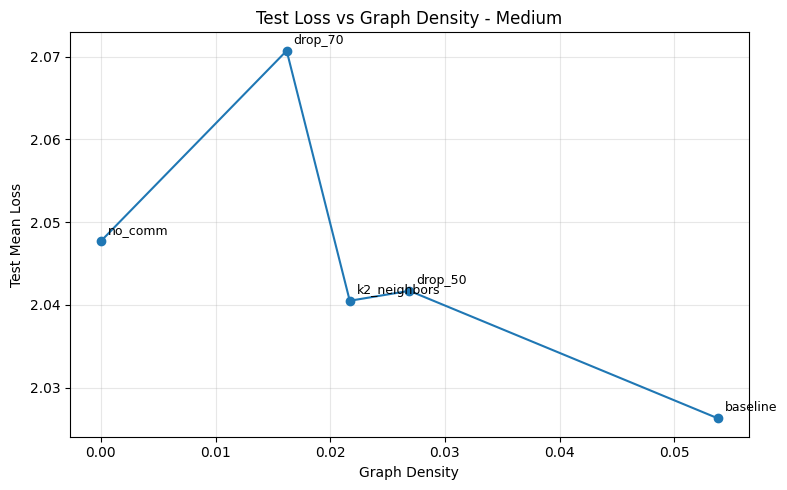

In [ ]:
def plot_test_loss_vs_density(summary_df):
    df_sub = summary_df[summary_df["dataset"] == "medium"].copy()
    df_sub = df_sub.sort_values("density")

    plt.figure(figsize=(8, 5))
    plt.plot(df_sub["density"], df_sub["test_mean_loss"], marker="o")

    for _, row in df_sub.iterrows():
        plt.annotate(
            row["experiment"],
            (row["density"], row["test_mean_loss"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    plt.title("Test Loss vs Graph Density - Medium")
    plt.xlabel("Graph Density")
    plt.ylabel("Test Mean Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_test_loss_vs_density(summary_df)

This figure shows how graph density affects the test loss for the medium dataset under different ablation settings. The baseline has the highest density and also gives the lowest loss, which means better communication between agents helps the model perform better.

As the graph density decreases, the loss generally increases, showing that reducing communication makes it harder for agents to share information. However, the change is not very large. The drop_50 and k2_neighbors settings are still close to the baseline, while drop_70 gives the highest loss.

Interestingly, the no_comm setting does not give the worst loss, even though there is no communication. This is likely because the model can still learn from local observations and the dataset is dominated by action 20. Because of this, communication helps, but it is not the only factor affecting performance.

Overall, this shows that communication structure matters, but the effect is relatively small, and the model is still able to perform reasonably well even when connections are reduced.

**Train metrics side by side**

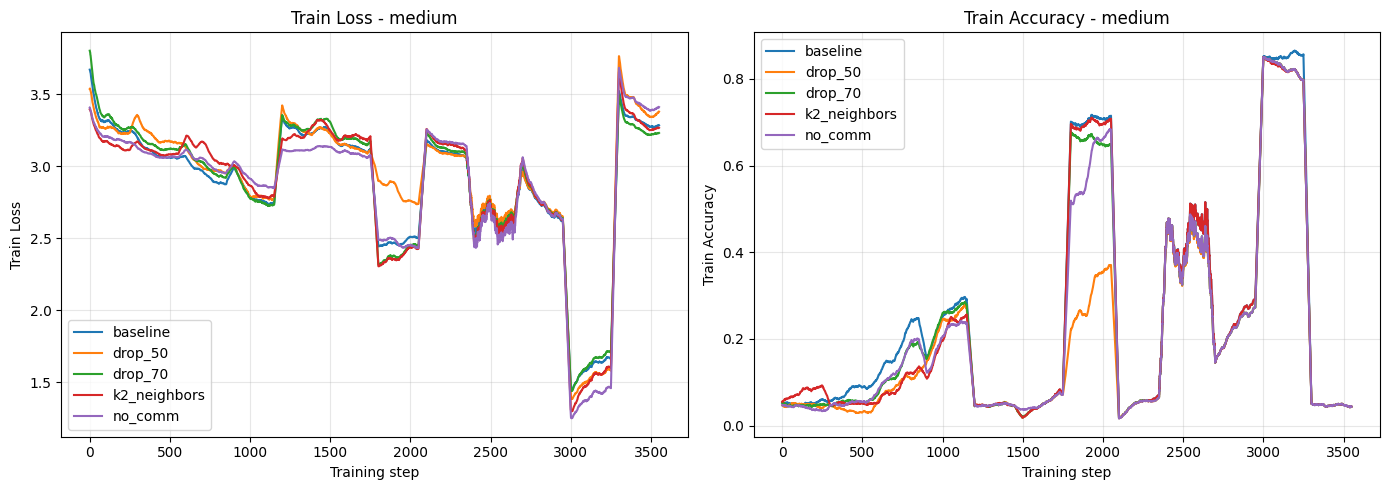

In [ ]:
def moving_average(x, window=50):
    if len(x) < window:
        return np.array(x)
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_train_metrics_side_by_side(experiment_results, dataset_name, smooth_window=50):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for mode, result in experiment_results[dataset_name].items():
        y = moving_average(result["train_loss_history"], window=smooth_window)
        axes[0].plot(y, label=mode)
    axes[0].set_title(f"Train Loss - {dataset_name}")
    axes[0].set_xlabel("Training step")
    axes[0].set_ylabel("Train Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    for mode, result in experiment_results[dataset_name].items():
        y = moving_average(result["train_acc_history"], window=smooth_window)
        axes[1].plot(y, label=mode)
    axes[1].set_title(f"Train Accuracy - {dataset_name}")
    axes[1].set_xlabel("Training step")
    axes[1].set_ylabel("Train Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_train_metrics_side_by_side(experiment_results, "medium", smooth_window=50)

**Reference adjacency plot for presentation**

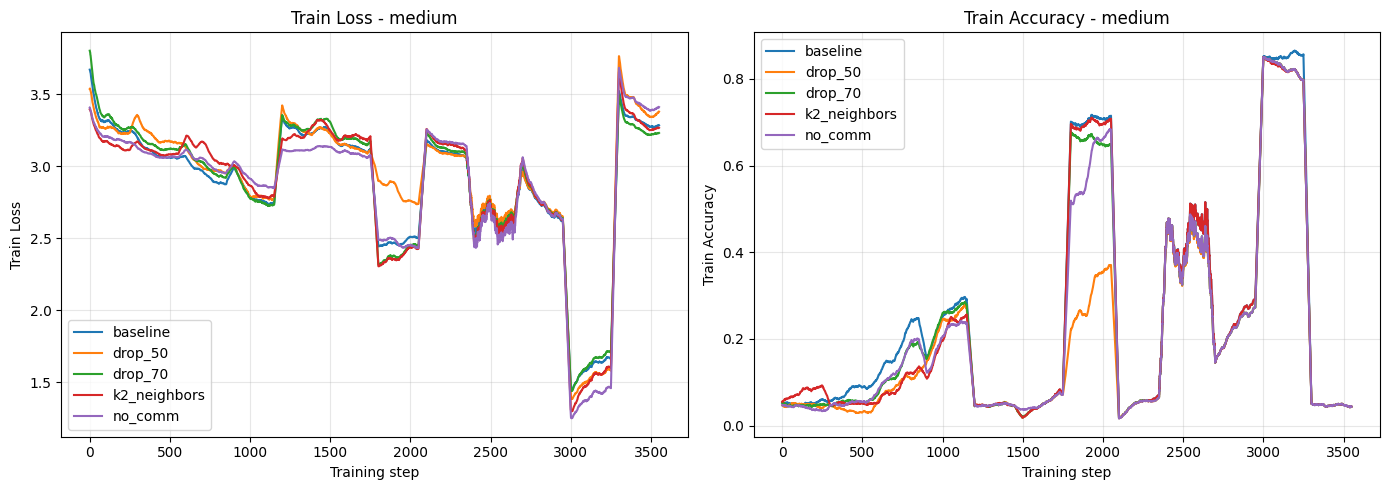

In [ ]:
def moving_average(x, window=50):
    if len(x) < window:
        return np.array(x)
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_train_metrics_side_by_side(experiment_results, dataset_name, smooth_window=50):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Train Loss
    for mode, result in experiment_results[dataset_name].items():
        y = moving_average(result["train_loss_history"], window=smooth_window)
        axes[0].plot(y, label=mode)
    axes[0].set_title(f"Train Loss - {dataset_name}")
    axes[0].set_xlabel("Training step")
    axes[0].set_ylabel("Train Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Right: Train Accuracy
    for mode, result in experiment_results[dataset_name].items():
        y = moving_average(result["train_acc_history"], window=smooth_window)
        axes[1].plot(y, label=mode)
    axes[1].set_title(f"Train Accuracy - {dataset_name}")
    axes[1].set_xlabel("Training step")
    axes[1].set_ylabel("Train Accuracy")

    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_train_metrics_side_by_side(experiment_results, "medium", smooth_window=50)

**Example Ablated adjacency from the last training step**

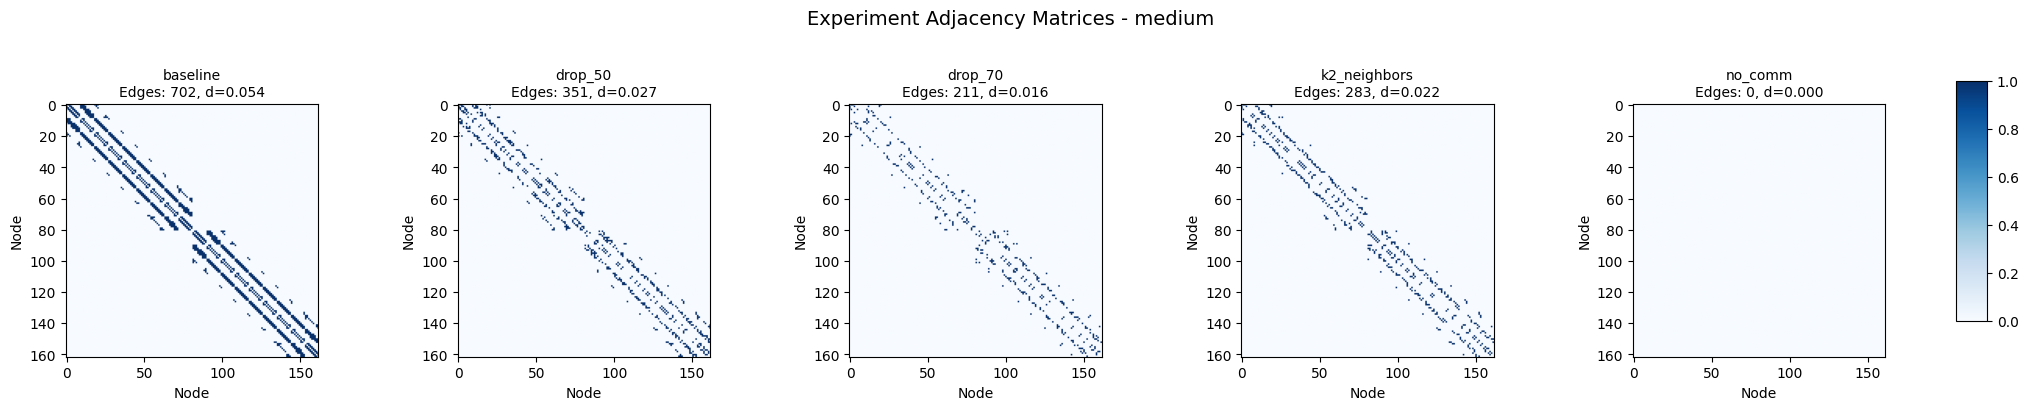

In [ ]:
def plot_experiment_adjacency_row(experiment_results, dataset_name, modes=None, adjacency_key="train_adjacency"):
    if modes is None:
        modes = ["baseline", "drop_50", "drop_70", "k2_neighbors", "no_comm"]

    fig, axes = plt.subplots(1, len(modes), figsize=(4.2 * len(modes), 4))
    if len(modes) == 1:
        axes = [axes]

    last_im = None

    for ax, mode in zip(axes, modes):
        adj = experiment_results[dataset_name][mode][adjacency_key]
        # adj = experiment_results[dataset_name][mode]["train_adjacency"]

        last_im = ax.imshow(adj, cmap="Blues", vmin=0, vmax=1)

        num_nodes = adj.shape[0]
        num_edges = int(np.sum(adj) / 2)
        possible_edges = num_nodes * (num_nodes - 1) / 2
        density = num_edges / possible_edges if possible_edges > 0 else 0.0

        ax.set_title(f"{mode}\nEdges: {num_edges}, d={density:.3f}", fontsize=10)
        ax.set_xlabel("Node")
        ax.set_ylabel("Node")

    fig.suptitle(f"Experiment Adjacency Matrices - {dataset_name}", fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.94, 0.92])

    if last_im is not None:
        cbar_ax = fig.add_axes([0.95, 0.2, 0.015, 0.6])
        fig.colorbar(last_im, cax=cbar_ax)

    plt.show()

plot_experiment_adjacency_row(experiment_results, "medium", adjacency_key="train_adjacency")

The adjacency visualization shows that the graph topology ablations were correctly applied to the original battlefield graph. The baseline graph is already sparse, with only a small portion of all possible connections active. In the drop_50 and drop_70 settings, the graph becomes progressively thinner as more edges are removed.

The diagonal pattern in all settings indicates that agents mainly communicate with nearby agents, meaning the communication is local rather than global. In the k2_neighbors setting, the structure becomes more restricted, where each agent communicates with only a small number of nearby agents, making the diagonal pattern thinner and more limited.

In the no_comm setting, all connections are removed, resulting in a completely empty adjacency matrix, where no communication occurs between agents.


